1. Carregando as bibliotecas

In [28]:
import pandas as pd
import numpy as np 
import plotly.express as px
import matplotlib.pyplot as plt

2. Carregando nosso arquivo em um DataFrame

In [29]:
#Carregando o arquivo CSV com os dados dos veículos
car_data = pd.read_csv('../vehicles.csv')

3. Preparando os dados

In [30]:
#Informações gerais sobre o dataframe
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  str    
 3   condition     51525 non-null  str    
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  str    
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  str    
 8   type          51525 non-null  str    
 9   paint_color   42258 non-null  str    
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  str    
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 7.7 MB


O dataframe tem 51.525 linhas e 13 colunas, com valores ausentes em model_year, cylinders, odometer, paint_color e is_4wd. A coluna is_4wd é a mais crítica, com cerca de 50% de nulos (25.953), o que sugere que o valor ausente significa "não é 4x4". Além disso, date_posted está como texto e precisa virar datetime, e model_year e cylinders devem ser convertidos para inteiro.

In [31]:
#Amostras aleatórias do dataframe
print(car_data.head())

   price  model_year           model  condition  cylinders fuel  odometer  \
0   9400      2011.0          bmw x5       good        6.0  gas  145000.0   
1  25500         NaN      ford f-150       good        6.0  gas   88705.0   
2   5500      2013.0  hyundai sonata   like new        4.0  gas  110000.0   
3   1500      2003.0      ford f-150       fair        8.0  gas       NaN   
4  14900      2017.0    chrysler 200  excellent        4.0  gas   80903.0   

  transmission    type paint_color  is_4wd date_posted  days_listed  
0    automatic     SUV         NaN     1.0  2018-06-23           19  
1    automatic  pickup       white     1.0  2018-10-19           50  
2    automatic   sedan         red     NaN  2019-02-07           79  
3    automatic  pickup         NaN     NaN  2019-03-22            9  
4    automatic   sedan       black     NaN  2019-04-02           28  


In [32]:
#Contagem de valores únicos na coluna 'is_4wd'
car_data['is_4wd'].value_counts(dropna=False)

is_4wd
NaN    25953
1.0    25572
Name: count, dtype: int64

A coluna is_4wd tem apenas dois estados: 1.0 (25.572 carros) e nulo (25.953), sem nenhum 0. Isso confirma que o nulo significa "não é 4x4", então pode ser preenchido com 0 e convertido para bool. Cerca de 50% dos carros são 4x4.

In [33]:
#Valores únicos nas colunas 'model_year' e 'cylinders'
print(car_data['model_year'].unique())
print(car_data['cylinders'].unique())

[2011.   nan 2013. 2003. 2017. 2014. 2015. 2012. 2008. 2018. 2009. 2010.
 2007. 2004. 2005. 2001. 2006. 1966. 1994. 2019. 2000. 2016. 1993. 1999.
 1997. 2002. 1981. 1995. 1996. 1975. 1998. 1985. 1977. 1987. 1974. 1990.
 1992. 1991. 1972. 1967. 1988. 1969. 1989. 1978. 1965. 1979. 1968. 1986.
 1980. 1964. 1963. 1984. 1982. 1973. 1970. 1955. 1971. 1976. 1983. 1954.
 1962. 1948. 1960. 1908. 1961. 1936. 1949. 1958. 1929.]
[ 6.  4.  8. nan  5. 10.  3. 12.]


Os valores de model_year variam de 1908 a 2019, com anos muito antigos (1908, 1929, 1936) que podem ser carros clássicos ou erros. Já cylinders tem apenas valores válidos (3, 4, 5, 6, 8, 10 e 12), sem inconsistências. Os nulos serão preenchidos com a mediana por model e as duas colunas convertidas para inteiro.

In [34]:
#Conversão de tipos de dados
car_data['model_year'] = car_data['model_year'].astype('Int64')
car_data['cylinders'] = car_data['cylinders'].astype('Int64')
car_data['date_posted'] = pd.to_datetime(car_data['date_posted'])
car_data['is_4wd'] = car_data['is_4wd'].fillna(0).astype(bool)
car_data['condition'] = car_data['condition'].astype('category')



Os tipos foram convertidos: model_year e cylinders para Int64 (aceita nulos), date_posted para datetime, is_4wd para bool (nulos = não é 4x4) e condition para category. Isso reduz memória e permite análises por data e categoria.

In [35]:
#Verificação da .info() após a conversão de tipos de dados
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   price         51525 non-null  int64         
 1   model_year    47906 non-null  Int64         
 2   model         51525 non-null  str           
 3   condition     51525 non-null  category      
 4   cylinders     46265 non-null  Int64         
 5   fuel          51525 non-null  str           
 6   odometer      43633 non-null  float64       
 7   transmission  51525 non-null  str           
 8   type          51525 non-null  str           
 9   paint_color   42258 non-null  str           
 10  is_4wd        51525 non-null  bool          
 11  date_posted   51525 non-null  datetime64[us]
 12  days_listed   51525 non-null  int64         
dtypes: Int64(2), bool(1), category(1), datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 6.3 MB


3.1 Verificando os valores duplicados

In [36]:
#Verificação de valores duplicados no dataframe
print('Duplicados:', car_data.duplicated().sum())

Duplicados: 0


Não há linhas duplicadas no dataframe (0 duplicados), então nenhuma remoção é necessária. Os dados seguem para a etapa de tratamento dos valores ausentes.

3.2 Verificando e tratando os valores ausentes

In [37]:
#Verificação de valores ausentes no dataframe
print('\nValores ausentes:')
print(car_data.isna().sum())

print('\nPorcentagem de valores ausentes:')
print((car_data.isna().mean() * 100).round(2))


Valores ausentes:
price              0
model_year      3619
model              0
condition          0
cylinders       5260
fuel               0
odometer        7892
transmission       0
type               0
paint_color     9267
is_4wd             0
date_posted        0
days_listed        0
dtype: int64

Porcentagem de valores ausentes:
price            0.00
model_year       7.02
model            0.00
condition        0.00
cylinders       10.21
fuel             0.00
odometer        15.32
transmission     0.00
type             0.00
paint_color     17.99
is_4wd           0.00
date_posted      0.00
days_listed      0.00
dtype: float64


Quatro colunas têm valores ausentes: paint_color (9.267, 17,99%), odometer (7.892, 15,32%), cylinders (5.260, 10,21%) e model_year (3.619, 7,02%). As demais estão completas, incluindo is_4wd, já tratada. A próxima etapa é preencher os nulos numéricos com a mediana agrupada e paint_color com 'unknown'.

In [38]:
#Tratando valores ausentes da coluna paint_color
car_data['paint_color'] = car_data['paint_color'].fillna('unknown')
print(car_data['paint_color'].isna().sum())
print(car_data['paint_color'].value_counts())

0
paint_color
white      10029
unknown     9267
black       7692
silver      6244
grey        5037
blue        4475
red         4421
green       1396
brown       1223
custom      1153
yellow       255
orange       231
purple       102
Name: count, dtype: int64


Os 9.267 nulos de paint_color foram preenchidos com 'unknown', e a coluna agora tem 0 valores ausentes. A cor mais comum é white (10.029), seguida de black e silver, e 'unknown' é a segunda maior categoria (cerca de 18%), então deve ser mantida separada em vez de ser imputada com a moda.

In [39]:
#Tratando valores ausentes da coluna 'cylinders'
cylinders_median = car_data.groupby('model')['cylinders'].transform('median')
car_data['cylinders'] = car_data['cylinders'].fillna(cylinders_median)  
print(car_data['cylinders'].isna().sum())

0


Os 5.260 nulos de cylinders foram preenchidos com a mediana agrupada por model, e a coluna agora tem 0 valores ausentes. Como carros do mesmo modelo costumam ter o mesmo número de cilindros, a imputação mantém a distribuição original.

In [40]:
#Tratando valores ausentes da coluna 'model_year'
model_year_median = car_data.groupby('model')['model_year'].transform('median').round()
car_data['model_year'] = car_data['model_year'].fillna(model_year_median)
print(car_data['model_year'].isna().sum())

0


Os 3.619 nulos de model_year foram preenchidos com a mediana agrupada por model (arredondada), e a coluna agora tem 0 valores ausentes. Carros do mesmo modelo tendem a ter anos próximos, então a imputação é coerente.

In [41]:
#Tratando valores ausentes da coluna 'odometer'
odometer_median = car_data.groupby(
    ['model', 'model_year']
)['odometer'].transform('median')

car_data['odometer'] = car_data['odometer'].fillna(odometer_median)

In [42]:
#Imprimindo a média de odômetro por modelo e ano do modelo
print(
    car_data.groupby(['model', 'model_year'])['odometer']
    .median()
    .head(20)
)

model     model_year
acura tl  1999          196000.0
          2001          177770.0
          2002          189200.0
          2003          142500.0
          2004          183000.0
          2005          169700.0
          2006          153643.5
          2007          133500.0
          2008          134460.0
          2009          131000.0
          2010          141000.0
          2011          189000.0
          2012          100000.0
          2013           94000.0
          2014          108850.0
bmw x5    2001          157146.0
          2002          163000.0
          2003          170000.0
          2004          127148.0
          2005          141060.5
Name: odometer, dtype: float64


In [43]:
# Tratamento dos valores ausentes em odometer

# 1. Mediana por modelo e ano
odometer_median = car_data.groupby(
    ['model', 'model_year']
)['odometer'].transform('median')

car_data['odometer'] = car_data['odometer'].fillna(odometer_median)

# 2. Para os casos que ainda ficaram ausentes,
#    usar a mediana apenas por modelo
odometer_median_model = car_data.groupby(
    'model'
)['odometer'].transform('median')

car_data['odometer'] = car_data['odometer'].fillna(odometer_median_model)

In [44]:
#Imprimindo a quantidade de valores ausentes na coluna 'odometer' após o tratamento
print(car_data['odometer'].isna().sum())

41


In [45]:
#Imprimindo os modelos e anos que ainda possuem valores ausentes na coluna 'odometer'
print(
    car_data.loc[
        car_data['odometer'].isna(),
        ['model', 'model_year']
    ]
)

                                   model  model_year
42     mercedes-benz benze sprinter 2500        2013
1642   mercedes-benz benze sprinter 2500        2013
2232   mercedes-benz benze sprinter 2500        2013
2731   mercedes-benz benze sprinter 2500        2013
4149   mercedes-benz benze sprinter 2500        2013
4681   mercedes-benz benze sprinter 2500        2013
5681   mercedes-benz benze sprinter 2500        2013
8975   mercedes-benz benze sprinter 2500        2013
10600  mercedes-benz benze sprinter 2500        2013
11541  mercedes-benz benze sprinter 2500        2013
11916  mercedes-benz benze sprinter 2500        2013
14796  mercedes-benz benze sprinter 2500        2013
14871  mercedes-benz benze sprinter 2500        2013
17473  mercedes-benz benze sprinter 2500        2013
17493  mercedes-benz benze sprinter 2500        2013
18103  mercedes-benz benze sprinter 2500        2013
18811  mercedes-benz benze sprinter 2500        2013
19877  mercedes-benz benze sprinter 2500      

In [46]:
#Verificação de quais são os valores ausentes na coluna 'odometer' após o tratamento
print(
    car_data.loc[
        car_data['odometer'].isna(),
        'model'
    ].value_counts()
)

model
mercedes-benz benze sprinter 2500    41
Name: count, dtype: int64


In [47]:
# modelos que contêm "sprinter" (com ou sem "benze")
sprinter_models = car_data.loc[
    car_data['model'].str.contains('sprinter', case=False),
    'model'
]

# contagem de cada variação
print(sprinter_models.value_counts())

model
mercedes-benz benze sprinter 2500    41
Name: count, dtype: int64


Não irei deletar esses valores pois podera ser usado para outras analises.

4. Criação de Histograma

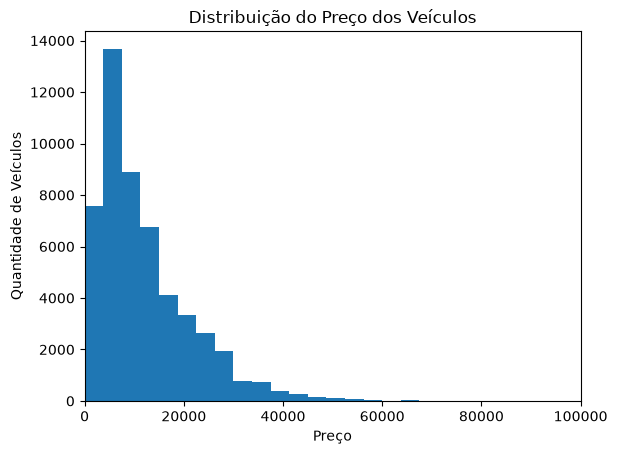

In [48]:
#Histograma distribuição de Preço dos veículos
plt.hist(car_data['price'], bins=100)
plt.xlabel('Preço')
plt.ylabel('Quantidade de Veículos')
plt.title('Distribuição do Preço dos Veículos')
plt.xlim(0, 100000)
plt.show()

A distribuição de price é assimétrica à direita: a maioria dos veículos custa menos de 30.000, com pico entre 5.000 e 8.000. Há uma cauda longa até cerca de 65.000, com poucos carros acima de 40.000. Por isso a mediana representa melhor o preço típico do que a média.

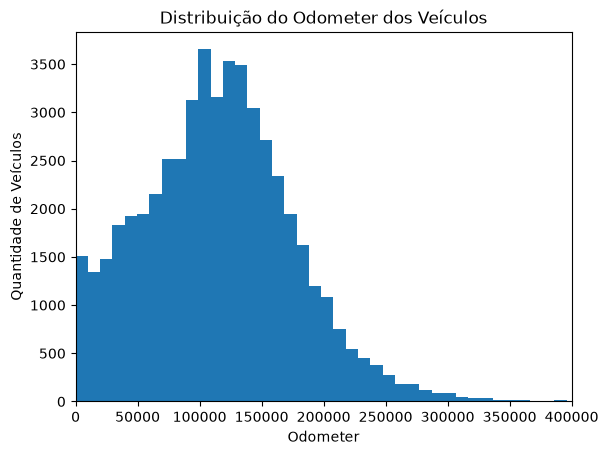

In [49]:
#Histograma da coluna 'odometer' 
plt.hist(car_data['odometer'], bins=100)
plt.xlabel('Odometer')
plt.ylabel('Quantidade de Veículos')
plt.title('Distribuição do Odometer dos Veículos') 
plt.xlim(0, 400000)
plt.show()


A distribuição de odometer é aproximadamente normal, com leve assimetria à direita: a maioria dos veículos tem entre 70.000 e 180.000 de quilometragem, com pico próximo de 100.000 a 130.000. Há uma cauda longa até cerca de 350.000 e um pequeno aumento perto de 0, provavelmente carros novos ou seminovos. Como a assimetria é leve, média e mediana ficam próximas.

5. Gráficos de dispersão

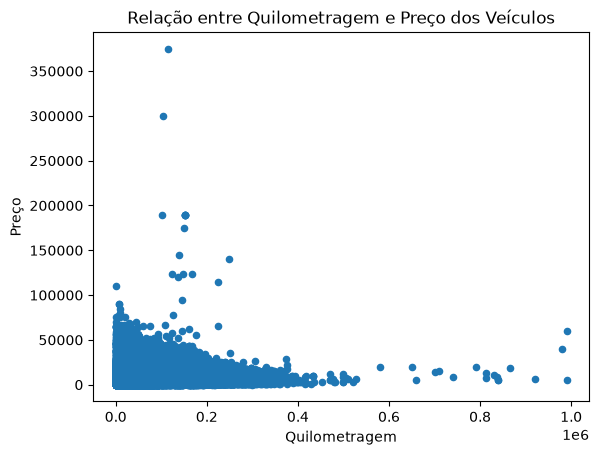

In [50]:
#Relação entre quilometragem e preço dos veículos
car_data.plot(x='odometer',
              y='price',
              kind='scatter')
plt.xlabel('Quilometragem')
plt.ylabel('Preço')
plt.title('Relação entre Quilometragem e Preço dos Veículos')
plt.show()

Existe uma relação negativa entre odometer e price: quanto maior a quilometragem, menor o preço, com a maioria dos carros concentrada abaixo de 400.000 e de 50.000. Há outliers de preço (entre 100.000 e 375.000) e de quilometragem (perto de 1.000.000), que devem ser tratados ou analisados separadamente.

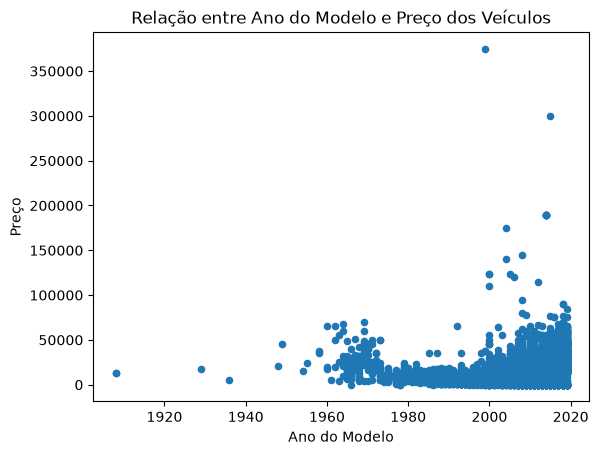

In [51]:
#Relação Preço e ano do modelo dos veículos
car_data.plot(x='model_year',
              y='price',
              kind='scatter')
plt.xlabel('Ano do Modelo')
plt.ylabel('Preço')
plt.title('Relação entre Ano do Modelo e Preço dos Veículos')
plt.show()

Existe uma relação positiva entre model_year e price: carros mais novos tendem a custar mais, com a maior concentração de anúncios a partir de 1990 e preços abaixo de 50.000. Carros anteriores a 1960 são raros e podem ser clássicos ou erros de digitação. Os outliers de preço (acima de 100.000, com pico perto de 375.000) aparecem quase todos em modelos após 1999 e devem ser tratados.

5. Boxplot 

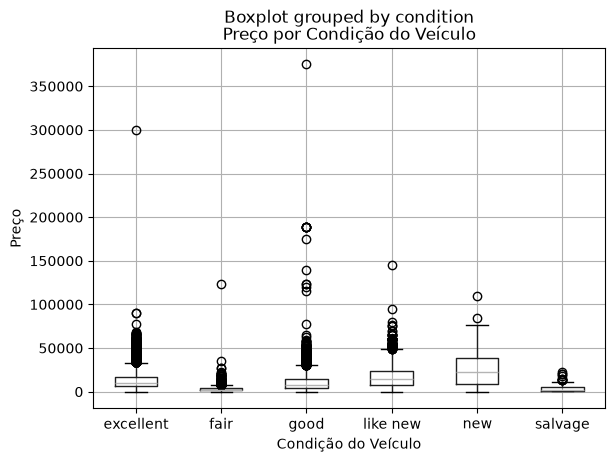

In [52]:
#Preço por condição do veículo
car_data.boxplot(column='price', by='condition')
plt.xlabel('Condição do Veículo')
plt.ylabel('Preço')
plt.title('Preço por Condição do Veículo') 
plt.show()


O preço mediano segue a condição do veículo: new tem a maior mediana e a maior dispersão, like new e excellent ficam no meio, e fair e salvage têm as menores medianas e caixas bem estreitas. Todas as categorias têm outliers de preço, com os mais extremos em good (cerca de 375.000) e excellent (300.000).

6. Gráfico de Barras

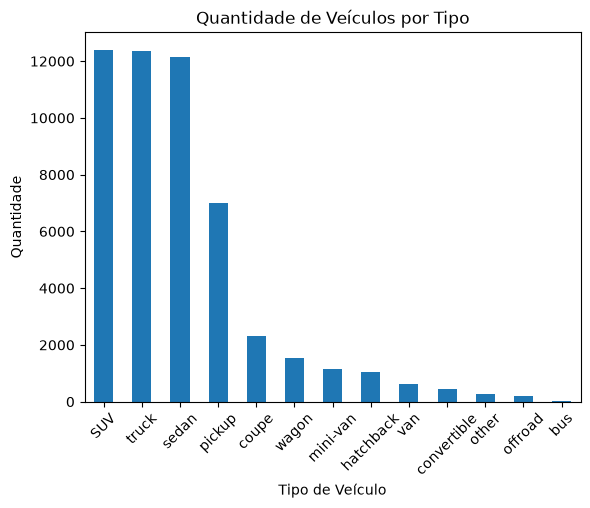

In [53]:
#Quantidade de veículos por tipo
car_data['type'].value_counts().plot(kind='bar')

plt.title('Quantidade de Veículos por Tipo')
plt.xlabel('Tipo de Veículo')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

Três tipos dominam o conjunto de dados: SUV, truck e sedan, cada um com cerca de 12.000 veículos. Em seguida vem pickup (cerca de 7.000), e os demais tipos (coupe, wagon, mini-van, hatchback, van, convertible, other, offroad e bus) têm menos de 2.500 anúncios cada. Como bus e offroad têm pouquíssimos casos, comparações de preço por tipo devem ser feitas com cautela.

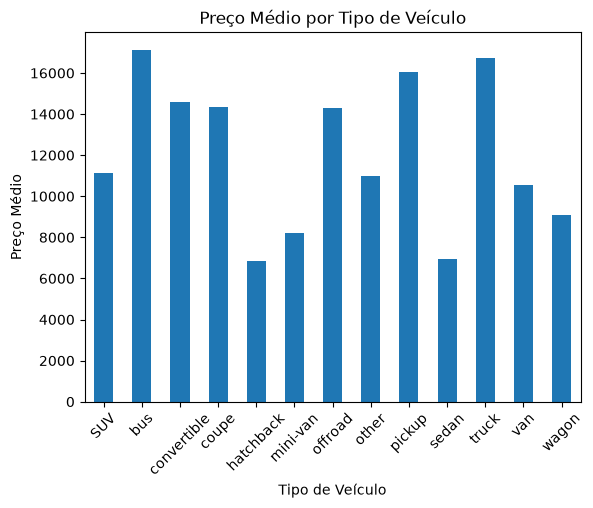

In [54]:
#Preço médio por tipo de veículo
car_data.groupby('type')['price'].mean().plot(kind='bar')

plt.title('Preço Médio por Tipo de Veículo')
plt.xlabel('Tipo de Veículo')
plt.ylabel('Preço Médio')
plt.xticks(rotation=45)
plt.show()


Os tipos com maior preço médio são bus (cerca de 17.000), truck (cerca de 16.700) e pickup (cerca de 16.000), enquanto hatchback e sedan têm os menores (cerca de 6.900). SUV fica no meio (cerca de 11.000), apesar de ser um dos tipos mais frequentes.

## Conclusão Geral

O conjunto de dados tem 51.525 anúncios de carros usados e 13 colunas. Havia valores ausentes em model_year, cylinders, odometer, paint_color e is_4wd, tratados com a mediana agrupada por modelo (e por ano, no caso de odometer), 'unknown' para cor e 0 para is_4wd. Os tipos de dados foram corrigidos e não há linhas duplicadas.

A análise mostrou que price e odometer têm distribuição assimétrica à direita, com outliers extremos de preço (até cerca de 375.000) e de quilometragem (perto de 1.000.000). Carros mais novos e com menor quilometragem custam mais, e o preço mediano segue a condição do veículo, de salvage até new.

SUV, truck e sedan dominam o mercado, com cerca de 12.000 anúncios cada, e bus, truck e pickup têm os maiores preços médios. Como a média é sensível a outliers, as próximas etapas devem tratar esses valores extremos, padronizar o nome benze e usar a mediana nas comparações.